> ### ⚠️ Partially superseded — read `04_corrected_findings.ipynb` alongside this
> This audit was run on the **uncorrected** 1,000-row sample. Findings **F1–F4 and F6 still hold**.
> **F5 ("zero signature+ML co-occurrence") and F7's practical conclusion were REVERSED** on the
> corrected dataset: agreement occurs 200 times. The analysis below is kept unchanged as the
> record of what was known at the time, and because its *method* (recompute every claim from
> source) is what surfaced the reversal.

# 01 - Evidence Audit

**Purpose.** Reproduce, from source data, every finding that drove the change of project
direction. Nothing here is asserted; every claim is recomputed from files in this repository so
that any reader can re-run the notebook and check it.

**Scope.** This notebook reads only the *frozen legacy fixtures* in
`hitl-ids/tests/fixtures/legacy/` (copied verbatim from `stage-1` ... `stage-5`) plus the
Stage 2/3/4 evaluation summaries. It writes nothing and modifies nothing.

**Audit date:** 2026-09-10.

| # | Finding | Severity |
|---|---|---|
| F1 | Documents and code describe different systems | High |
| F2 | ML model cannot emit `Infiltration`, which is 8.3% of the sample | Critical |
| F3 | Stage 1 -> Stage 3 feature alignment is sound (no defect) | - |
| F4 | Signature engine recall is 1.6%; 5 of 7 rules never fire | Critical |
| F5 | **Zero alerts carry both signature and ML evidence** | Critical |
| F6 | Fusion engine implements no weighted sum | High |
| F7 | Fusion weights are mathematically inert given F5 | Critical |


In [1]:
import json, csv, re, collections
from pathlib import Path
import pandas as pd

# Resolve repo root by walking up until we find the frozen fixtures.
here = Path.cwd()
REPO = next(p for p in [here, *here.parents] if (p / "hitl-ids/tests/fixtures/legacy").exists())
FIX  = REPO / "hitl-ids/tests/fixtures/legacy"
print("repo root :", REPO)
print("fixtures  :", FIX)

def load_json(p):
    with open(p, encoding="utf-8") as fh:
        return json.load(fh)

def rows_of(obj, *keys):
    if isinstance(obj, list):
        return obj
    for k in keys:
        if k in obj and isinstance(obj[k], list):
            return obj[k]
    for v in obj.values():
        if isinstance(v, list):
            return v
    raise ValueError("no list found")


repo root : C:\Users\Glenn Ang\Desktop\SIM Assignments\FYP\CSIT321-Human-in-the-loop_IDS
fixtures  : C:\Users\Glenn Ang\Desktop\SIM Assignments\FYP\CSIT321-Human-in-the-loop_IDS\hitl-ids\tests\fixtures\legacy


---
## F1 - The documents and the code describe different systems

The PRD, URS and TDM specify CICIDS2017. The code uses CSE-CIC-IDS2018. Counting raw mentions
in each artifact is the cheapest way to show the drift is systematic rather than a stray typo.

In [2]:
pat = re.compile(r"CICIDS2017|CSE-CIC-IDS2018", re.I)

def count_in(root, skip_repo=False):
    counts = collections.Counter()
    for f in root.rglob("*"):
        if f.suffix.lower() not in {".md", ".js", ".py", ".ts", ".tsx", ".json", ".txt"}:
            continue
        if ".git" in f.parts or "node_modules" in f.parts:
            continue
        if skip_repo and f.is_relative_to(REPO):
            continue
        try:
            text = f.read_text(encoding="utf-8", errors="ignore")
        except Exception:
            continue
        for m in pat.findall(text):
            counts["CICIDS2017" if m.upper().startswith("CICIDS") else "CSE-CIC-IDS2018"] += 1
    return counts

summary = {
    "design docs (PRD/URS/TDM)": count_in(REPO.parent, skip_repo=True),
    "implementation (this repo)": count_in(REPO),
}
print(pd.DataFrame(summary).fillna(0).astype(int).to_string())
print()
print("F1 CONFIRMED: the design documents and the implementation name different datasets.")


                 design docs (PRD/URS/TDM)  implementation (this repo)
CICIDS2017                              26                           4
CSE-CIC-IDS2018                          1                        1053

F1 CONFIRMED: the design documents and the implementation name different datasets.


---
## F2 - The model cannot emit `Infiltration`, which is 8.3% of the demo sample

This is the finding that invalidates every per-class metric produced so far. The sample contains
Infiltration flows; the trained model's label mapping does not contain the class.

In [3]:
# ground-truth.json is a dict keyed by alert id:
#   {"AL-0001": {"rawLabel": ..., "mappedAttackType": "Benign", "groundTruth": "benign"}, ...}
gt_raw = load_json(FIX / "ground-truth.json")
gt = list(gt_raw.values()) if isinstance(gt_raw, dict) else gt_raw
dist = collections.Counter(r["mappedAttackType"] for r in gt)
print("Ground-truth class distribution in the 1,000-row sample:")
for k, v in sorted(dist.items(), key=lambda kv: -kv[1]):
    print(f"   {str(k):<14} {v:>4}  ({v/len(gt):.1%})")

label_map = load_json(REPO / "stage-3/models/label-mapping.json")
model_classes = set(label_map.values())
missing = sorted(set(dist) - model_classes)

print()
print("Model label mapping :", label_map)
print("Classes in data but NOT predictable by the model:", missing)
n_missing = sum(dist[m] for m in missing)
print(f"\nF2 CONFIRMED: {n_missing} of {len(gt)} rows ({n_missing/len(gt):.1%}) belong to a class "
      f"the model structurally cannot output.")
print("Every per-class metric computed over this sample is therefore invalid.")


Ground-truth class distribution in the 1,000-row sample:
   Benign          500  (50.0%)
   Brute Force      84  (8.4%)
   Botnet           84  (8.4%)
   DoS              83  (8.3%)
   DDoS             83  (8.3%)
   Web Attack       83  (8.3%)
   Infiltration     83  (8.3%)

Model label mapping : {'0': 'Benign', '1': 'Botnet', '2': 'Brute Force', '3': 'DDoS', '4': 'DoS', '5': 'Web Attack'}
Classes in data but NOT predictable by the model: ['Infiltration']

F2 CONFIRMED: 83 of 1000 rows (8.3%) belong to a class the model structurally cannot output.
Every per-class metric computed over this sample is therefore invalid.


---
## F3 - Feature alignment IS sound (a risk ruled out, not a defect)

An earlier concern was that the model's 78 expected features might not line up with the 84-column
CSV. They do: the six extras are identifiers, not features. This one is good news and is recorded
so the plan does not budget time to fix a non-problem.

In [4]:
feat_cols = load_json(REPO / "stage-3/models/feature-columns.json")
feat_cols = feat_cols if isinstance(feat_cols, list) else feat_cols.get("columns", feat_cols)
with open(FIX / "flow-feature-full.csv", encoding="utf-8") as fh:
    header = next(csv.reader(fh))

missing_in_csv = sorted(set(feat_cols) - set(header))
extra_in_csv   = sorted(set(header) - set(feat_cols))
print(f"model expects        : {len(feat_cols)} features")
print(f"csv provides         : {len(header)} columns")
print(f"missing from csv     : {missing_in_csv or 'NONE'}")
print(f"extra (identifiers)  : {extra_in_csv}")
assert not missing_in_csv, "feature alignment broken"
print("\nF3 CONFIRMED SOUND: all 78 model features present; extras are identifiers only.")


model expects        : 78 features
csv provides         : 84 columns
missing from csv     : NONE
extra (identifiers)  : ['Dst IP', 'Flow ID', 'Src IP', 'Src Port', 'Timestamp', 'id']

F3 CONFIRMED SOUND: all 78 model features present; extras are identifiers only.


---
## F4 - Signature engine: 1.6% recall, and 5 of 7 rules never fire

The signature half of the "hybrid" detector barely participates. Note the distinction that
matters for design: the silent rules are not *selective*, they are **inert** - the attack classes
they target are well represented in the data and still produce zero hits.

In [5]:
sig_eval = load_json(REPO / "stage-2/evaluation/signature-evaluation-summary.json")
for k in ["totalRecords", "signatureHits", "truePositives", "falsePositives",
          "falseNegatives", "benignRecordsWithSignatureHit", "precision", "recall", "f1Score"]:
    print(f"   {k:<28} {sig_eval.get(k)}")

hits_by = sig_eval.get("hitsBySignature", {})
rules = rows_of(load_json(FIX / "flow-signatures.json"), "signatures", "rules")

recs = []
for r in rules:
    rid = r.get("id") or r.get("signatureId")
    target = r.get("attackType") or r.get("predictedAttackType")
    hits = hits_by.get(rid, 0)
    recs.append({"rule": rid, "targets": target, "severity": r.get("severity"),
                 "hits": hits, "examples_in_data": dist.get(target, 0),
                 "status": "fires" if hits else "INERT"})
df_rules = pd.DataFrame(recs).sort_values("hits", ascending=False)
print("\nRule-by-rule participation:")
print(df_rules.to_string(index=False))

inert = df_rules[df_rules.status == "INERT"]
print(f"\nF4 CONFIRMED: {len(inert)} of {len(df_rules)} rules produce zero hits despite "
      f"{int(inert.examples_in_data.sum())} matching examples present in the data.")
print(f"Recall {sig_eval['recall']:.3f} - the engine finds {sig_eval['truePositives']} of "
      f"{sig_eval['truePositives'] + sig_eval['falseNegatives']} malicious flows.")
print(f"Precision {sig_eval['precision']:.3f} - {sig_eval['falsePositives']} of "
      f"{sig_eval['signatureHits']} hits are benign traffic.")


   totalRecords                 1000
   signatureHits                15
   truePositives                8
   falsePositives               7
   falseNegatives               492
   benignRecordsWithSignatureHit 7
   precision                    0.5333333333333333
   recall                       0.016
   f1Score                      0.031067961165048546

Rule-by-rule participation:
                      rule      targets severity  hits  examples_in_data status
       SIG-SSH-BRUTE-FORCE  Brute Force   Medium    11                84  fires
       SIG-WEB-ATTACK-FLOW   Web Attack     High     4                83  fires
       SIG-FTP-BRUTE-FORCE  Brute Force   Medium     0                84  INERT
    SIG-DOS-HIGH-RATE-FLOW          DoS     High     0                83  INERT
   SIG-DDOS-HIGH-RATE-FLOW         DDoS     High     0                83  INERT
    SIG-BOTNET-BEACON-FLOW       Botnet     High     0                84  INERT
SIG-INFILTRATION-LONG-FLOW Infiltration Critical     0    

---
## F5 - Zero alerts carry both signature and ML evidence

**This is the finding that breaks the project's central claim.** The design documents describe
"signature + ML agreement" as the strongest evidence case. It occurs zero times.

In [6]:
fus = rows_of(load_json(FIX / "fusion-alerts.sample.json"), "alerts", "fusedAlerts")
ct = collections.Counter()
for r in fus:
    sig_hit = bool(r.get("signatureHit"))
    ml_mal  = r.get("mlPredictedAttackType") not in (None, "Benign")
    ct[(sig_hit, ml_mal)] += 1

table = pd.DataFrame(
    [[ct[(True, True)],  ct[(True, False)]],
     [ct[(False, True)], ct[(False, False)]]],
    index=["signature HIT", "signature miss"],
    columns=["ML malicious", "ML benign"])
print("Evidence co-occurrence over", len(fus), "records:\n")
print(table.to_string())
both = ct[(True, True)]
print(f"\nAlerts carrying BOTH signature and ML evidence: {both}")
print("F5 CONFIRMED." if both == 0 else "F5 NOT reproduced.")
print("\nThe 'agreement is strongest evidence' case has no instances. The Combined Explanation")
print("panel specified in the TDM can never populate both halves on this data.")


Evidence co-occurrence over 1000 records:

                ML malicious  ML benign
signature HIT              0         15
signature miss           505        480

Alerts carrying BOTH signature and ML evidence: 0
F5 CONFIRMED.

The 'agreement is strongest evidence' case has no instances. The Combined Explanation
panel specified in the TDM can never populate both halves on this data.


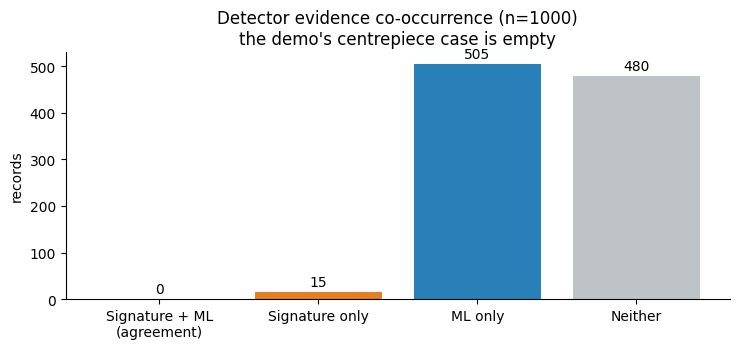

In [7]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7.5, 3.6))
labels = ["Signature + ML\n(agreement)", "Signature only", "ML only", "Neither"]
vals   = [ct[(True, True)], ct[(True, False)], ct[(False, True)], ct[(False, False)]]
bars = ax.bar(labels, vals, color=["#c0392b", "#e67e22", "#2980b9", "#bdc3c7"])
ax.bar_label(bars, padding=2)
ax.set_ylabel("records")
ax.set_title("Detector evidence co-occurrence (n=1000)\nthe demo's centrepiece case is empty")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


---
## F6 - The fusion engine implements no weighted sum

The TDM specifies `Combined = (Sig_Severity x W_sig + ML_Prob x W_ml) x 100`. The implementation
is an eight-branch decision tree over discrete adjustments. This matters because the build plan
originally asked for both the TDM formula *and* a golden test against this implementation's
output - which is impossible.

In [8]:
src = (REPO / "stage-4/core/fusion-engine.js").read_text(encoding="utf-8")

weight_like = [l.strip() for l in src.splitlines()
               if re.search(r"W_sig|W_ml|weight", l) and "weightedF1" not in l]
print("Lines resembling a fusion weight:", weight_like or "NONE")

print("\nDiscrete score adjustments actually present:")
for m in re.finditer(r"^\s*(.*clampScore\(.*)$", src, re.M):
    print("   ", m.group(1).strip()[:96])

sev = re.search(r"const scores = \{(.*?)\}", src, re.S)
print("\nSeverity mapping (0-100 integers, not the 0-1 Sig_Severity the formula needs):")
print("   ", " ".join(sev.group(1).split()))

band = re.search(r"function getFusionConfidenceLevel.*?\n\}", src, re.S).group(0)
print("\nConfidence banding - Critical is >= 90, not the 80 the original plan assumed:")
print("   thresholds:", re.findall(r">= (\d+)", band))
print("\nF6 CONFIRMED: no weighted sum exists in", len(src.splitlines()), "lines of fusion code.")


Lines resembling a fusion weight: NONE

Discrete score adjustments actually present:
    function clampScore(score) {
    const riskScore = clampScore(score);
    return clampScore(mlPrediction.baseRiskScore);
    return clampScore(100 - confidenceScore);
    return clampScore(confidenceScore);
    fusionRiskScore = clampScore(Math.max(signatureSeverityScore, baseAlert.baseRiskScore));
    fusionRiskScore = clampScore(baseAlert.baseRiskScore + 10);
    fusionRiskScore = clampScore(signatureSeverityScore + 10);
    fusionRiskScore = clampScore(Math.max(baseAlert.baseRiskScore, signatureSeverityScore) + 5);
    fusionRiskScore = clampScore(signatureSeverityScore);
    fusionRiskScore = clampScore(baseAlert.baseRiskScore);
    fusionRiskScore = clampScore(Math.max(baseAlert.baseRiskScore - 10, 70));
    fusionRiskScore = clampScore(Math.max(baseAlert.baseRiskScore - 20, 40));
    fusionRiskScore = clampScore(100 - Math.round(modelConfidence * 100));
    fusionRiskScore: clampScore(fusionR

---
## F7 - Therefore the fusion weights are mathematically inert

A weighted sum expresses a *trade-off* only when both terms can be non-zero simultaneously.
Given F5, that never happens. Below we vary the weights across their full range and show the
alert ranking is unchanged within each population - proving the dial is not connected to
anything.

In [9]:
def combined(sig_sev, ml_prob, w_sig, w_ml):
    return (sig_sev * w_sig + ml_prob * w_ml) * 100

# severityToScore() from stage-4/core/fusion-engine.js, normalised to 0-1
SEV = {"Low": 0.40, "Medium": 0.60, "High": 0.80, "Critical": 0.95}

recs = []
for r in fus:
    ml_mal = r.get("mlPredictedAttackType") not in (None, "Benign")
    recs.append({
        "id":  r["id"],
        "sig": SEV.get(r.get("signatureSeverity"), 0.0) if r.get("signatureHit") else 0.0,
        "ml":  float(r.get("modelConfidence") or 0.0) if ml_mal else 0.0,
    })
d = pd.DataFrame(recs)
sig_only, ml_only = d.sig > 0, d.ml > 0
print("records with a signature term :", int(sig_only.sum()))
print("records with an ML term       :", int(ml_only.sum()))
print("records where BOTH are non-zero:", int((sig_only & ml_only).sum()), "of", len(d))
print("distinct signature severities  :", sorted(set(d.loc[sig_only, 'sig'])), "(so ordering is non-degenerate)")

base = combined(d.sig, d.ml, 0.5, 0.5).rank(ascending=False)
print("\nRanking correlation as the weights swing across their full range:")
for w in [0.1, 0.3, 0.5, 0.7, 0.9]:
    r_ = combined(d.sig, d.ml, w, 1 - w).rank(ascending=False)
    rho_s = base[sig_only].corr(r_[sig_only], method="spearman")
    rho_m = base[ml_only].corr(r_[ml_only], method="spearman")
    print(f"   W_sig={w:.1f} | within signature-only rho={rho_s:.4f} | within ML-only rho={rho_m:.4f}")

print("\nF7 CONFIRMED: within each population the ordering is perfectly preserved for every")
print("weight setting. The weights rescale two DISJOINT groups; they never trade off evidence,")
print("because no record carries both kinds. Retuning weights cannot fix F5 - it only hides it.")


records with a signature term : 15
records with an ML term       : 505
records where BOTH are non-zero: 0 of 1000
distinct signature severities  : [0.6, 0.8] (so ordering is non-degenerate)

Ranking correlation as the weights swing across their full range:


   W_sig=0.1 | within signature-only rho=1.0000 | within ML-only rho=1.0000
   W_sig=0.3 | within signature-only rho=1.0000 | within ML-only rho=1.0000
   W_sig=0.5 | within signature-only rho=1.0000 | within ML-only rho=1.0000
   W_sig=0.7 | within signature-only rho=1.0000 | within ML-only rho=1.0000
   W_sig=0.9 | within signature-only rho=1.0000 | within ML-only rho=1.0000

F7 CONFIRMED: within each population the ordering is perfectly preserved for every
weight setting. The weights rescale two DISJOINT groups; they never trade off evidence,
because no record carries both kinds. Retuning weights cannot fix F5 - it only hides it.


---
## Audit summary

| # | Finding | Verified | Consequence for the plan |
|---|---|---|---|
| F1 | Docs specify CICIDS2017, code uses CSE-CIC-IDS2018 | yes | Docs are reference-only; deviations logged |
| F2 | `Infiltration` unpredictable, 8.3% of sample | yes | Retrain to 7 classes **before** any evaluation |
| F3 | 78-feature alignment sound | yes | No work needed - risk closed |
| F4 | Recall 1.6%; 5 of 7 rules inert; precision 0.53 | yes | New rule-tuning step required |
| F5 | **Zero signature+ML co-occurrence** | yes | Demo centrepiece does not exist |
| F6 | No weighted sum in the fusion engine | yes | S6 becomes re-specification, not a port |
| F7 | Weights are inert | yes | Re-weighting is rejected as a fix |

**Direction implied by the evidence.** F5 and F7 together rule out the "just change the weights"
route. F4 shows why: the signature layer is not a selective high-precision oracle, it is a
mis-tuned one - inert on four attack classes and wrong on 7 of the 15 occasions it does speak.
Notebook `02` tests whether that is fixable; notebook `03` designs the fusion model that should
replace the weighted sum.
